# Customer Lifetime Value Auto Insurance

## Contents
1. Business Problem Understanding  
2. Data Understanding  
3. Data Preprocessing  
4. Modeling 
5. Conclusion
6. Recommendation


## 1. Business Problem Understanding

**Context**

Customer Lifetime Value (CLV) adalah estimasi nilai total yang dapat diberikan pelanggan kepada perusahaan selama hubungan bisnis berlangsung. Dalam industri auto insurance, CLV penting untuk membantu perusahaan memahami nilai jangka panjang setiap pelanggan, sehingga keputusan bisnis tidak hanya berfokus pada hasil jangka pendek.

Pemahaman terhadap CLV dapat membantu perusahaan menyusun strategi pemasaran, retensi, dan pengelolaan pelanggan secara lebih tepat untuk menjaga profitabilitas.

**Problem Statement**

Perusahaan auto insurance menghadapi tantangan dalam mengidentifikasi pelanggan yang memberikan nilai tinggi dan rendah bagi perusahaan. Tanpa pemahaman tersebut, strategi pemasaran dan retensi berisiko kurang efektif karena semua pelanggan diperlakukan dengan pendekatan yang sama.

Oleh karena itu, perusahaan memerlukan pendekatan yang dapat memperkirakan nilai CLV pelanggan agar keputusan bisnis dapat dilakukan dengan lebih tepat sasaran.

**Goals**

Project ini bertujuan membangun model prediktif untuk memperkirakan Customer Lifetime Value (CLV) pelanggan. Hasil prediksi diharapkan dapat membantu perusahaan mengenali pelanggan yang bernilai tinggi, menentukan prioritas strategi retensi, dan mendukung pengambilan keputusan bisnis.

Stakeholder yang dapat menggunakan hasil model ini adalah **tim marketing**, **tim customer retention/CRM**, dan **manajemen bisnis**. Model dapat digunakan saat perusahaan ingin menyusun strategi pemasaran, program loyalitas, atau evaluasi nilai pelanggan.

**Analytic Approach**

Analisis dilakukan untuk memahami hubungan antara karakteristik pelanggan dengan nilai Customer Lifetime Value (CLV). Setelah itu, akan dibangun model machine learning berbasis regresi untuk memprediksi nilai CLV pelanggan.

**Metric Evaluation**

Evaluasi model pada project ini menggunakan **RMSE**, **MAE**, dan **R-squared**. RMSE dan MAE digunakan untuk mengukur besar error prediksi, sedangkan R-squared digunakan untuk melihat seberapa baik model menjelaskan variasi target. Model yang baik diharapkan memiliki nilai RMSE dan MAE yang rendah, serta R-squared yang tinggi.

## 2. Data Understanding

In [1]:
import pandas as pd

df = pd.read_csv('data_customer_lifetime_value.csv')
print(f'Jumlah baris dan kolom: {df.shape}')
df.head()

Jumlah baris dan kolom: (5669, 11)


,Vehicle Class,Coverage,Renew Offer Type,EmploymentStatus,Marital Status,Education,Number of Policies,Monthly Premium Auto,Total Claim Amount,Income,Customer Lifetime Value
0,Four-Door Car,Extended,Offer1,Retired,Divorced,High School or Below,2.0,90.0,571.479602,11828.0,10083.486880
1,Four-Door Car,Basic,Offer1,Employed,Married,College,6.0,62.0,114.514440,44762.0,4943.386117
2,Two-Door Car,Basic,Offer1,Retired,Married,Master,2.0,62.0,257.248789,21514.0,11981.984810
3,Four-Door Car,Premium,Offer3,Disabled,Married,High School or Below,1.0,116.0,556.800000,17913.0,4550.856045
4,Two-Door Car,Basic,Offer3,Medical Leave,Married,High School or Below,1.0,62.0,355.820799,19030.0,2372.155492


Dataset terdiri dari **5.669 baris** dan **11 kolom**. Setiap baris merepresentasikan **satu customer**, sehingga data ini sudah cukup representatif untuk melihat gambaran awal customer pada bisnis auto insurance.

In [2]:
data_desc = pd.DataFrame({
    'feature': df.columns,
    'dtype': df.dtypes.astype(str).values,
    'n_unique': [df[col].nunique() for col in df.columns],
    'missing_values': [df[col].isna().sum() for col in df.columns]
})
data_desc

,feature,dtype,n_unique,missing_values
0,Vehicle Class,object,6,0
1,Coverage,object,3,0
2,Renew Offer Type,object,4,0
3,EmploymentStatus,object,5,0
4,Marital Status,object,3,0
5,Education,object,5,0
6,Number of Policies,float64,9,0
7,Monthly Premium Auto,float64,191,0
8,Total Claim Amount,float64,3274,0
9,Income,float64,3625,0


Hasil pengecekan menunjukkan terdapat **6 fitur kategorikal** dan **5 fitur numerik**, serta **tidak ada missing value**. Hal ini mengindikasikan bahwa data sudah cukup rapi untuk digunakan pada analisis awal dan proses modeling tanpa penanganan missing value terlebih dahulu.

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Number of Policies,5669.0,2.979361,2.393187,1.000000,1.000000,2.000000,4.000000,9.000000
Monthly Premium Auto,5669.0,93.026989,34.551795,61.000000,68.000000,82.000000,109.000000,297.000000
Total Claim Amount,5669.0,431.407103,287.558038,0.423310,266.932542,379.200000,549.986128,2759.794354
Income,5669.0,37868.188569,30490.490723,0.000000,0.000000,34322.000000,62464.000000,99934.000000
Customer Lifetime Value,5669.0,8029.874592,6916.708246,1898.007675,3954.344534,5800.188903,9031.214859,83325.381190


Berdasarkan statistik deskriptif, rata-rata `Customer Lifetime Value` adalah **8,029.87**, dengan median **5,800.19** dan nilai maksimum **83,325.38**. Selisih mean dan median yang cukup jauh ini menunjukkan bahwa distribusi CLV cenderung tidak simetris dan dipengaruhi oleh nilai yang sangat tinggi.

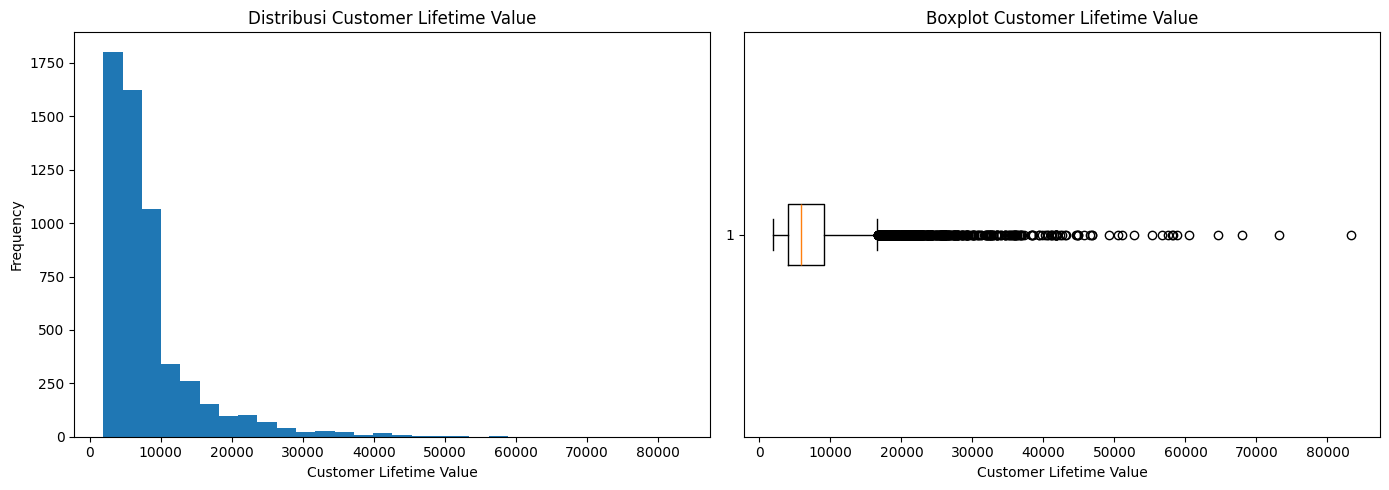

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Customer Lifetime Value'], bins=30)
axes[0].set_title('Distribusi Customer Lifetime Value')
axes[0].set_xlabel('Customer Lifetime Value')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['Customer Lifetime Value'], vert=False)
axes[1].set_title('Boxplot Customer Lifetime Value')
axes[1].set_xlabel('Customer Lifetime Value')

plt.tight_layout()
plt.show()

Histogram menunjukkan bahwa distribusi `Customer Lifetime Value` bersifat **right-skewed**, sedangkan boxplot memperlihatkan adanya beberapa **outlier**. Hal ini dapat menjadi indikasi bahwa hanya sebagian kecil customer yang memberikan nilai sangat tinggi bagi perusahaan.

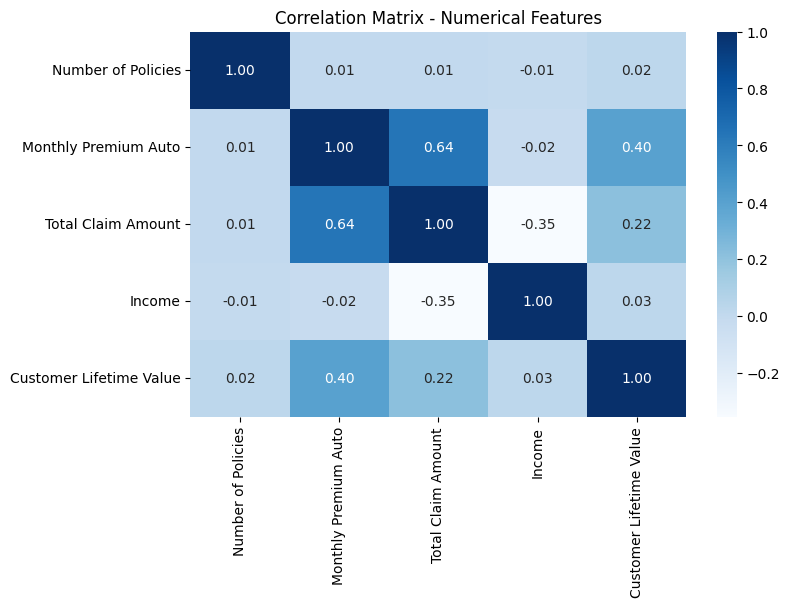

In [5]:
import numpy as np
import seaborn as sns

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

fig = plt.figure(figsize=(8, 5))
correlation = df[numeric_cols].corr()
sns.heatmap(correlation, annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Matrix - Numerical Features')
plt.show()

Berdasarkan correlation matrix, `Monthly Premium Auto` memiliki hubungan linear paling kuat dengan `Customer Lifetime Value` dengan nilai korelasi sekitar **0.40**, diikuti oleh `Total Claim Amount` sebesar **0.22**. Sementara itu, `Income` (**0.03**) dan `Number of Policies` (**0.02**) menunjukkan hubungan yang relatif lemah. Hal ini dapat menjadi indikasi bahwa premi bulanan lebih berhubungan dengan nilai jangka panjang customer dibanding fitur numerik lainnya.

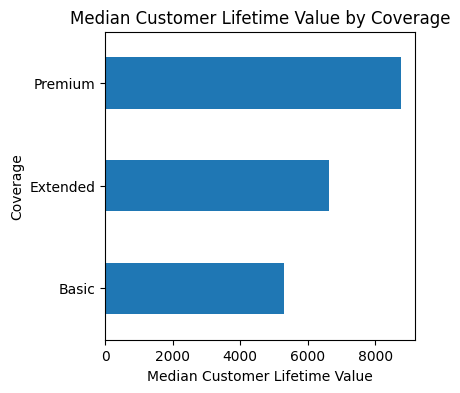

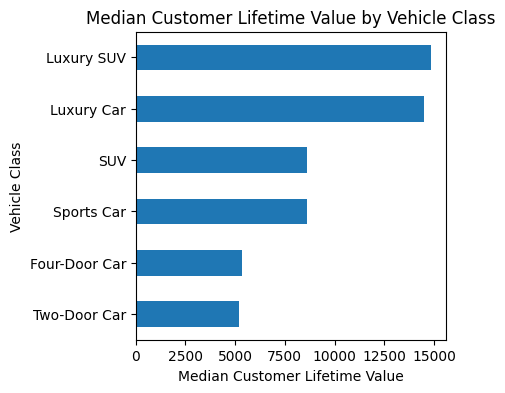

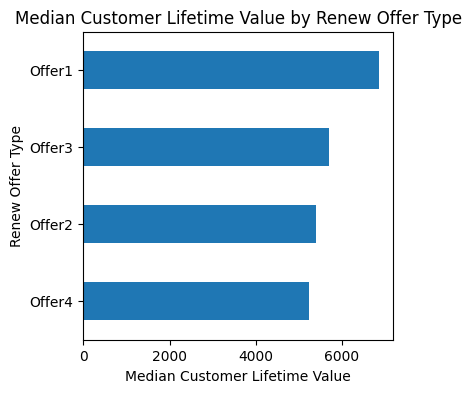

In [6]:
cat_features_to_analyze = ['Coverage', 'Vehicle Class', 'Renew Offer Type']

for col in cat_features_to_analyze:
    plt.figure(figsize=(4, 4))
    df.groupby(col)['Customer Lifetime Value'].median().sort_values().plot(kind='barh')
    plt.title(f'Median Customer Lifetime Value by {col}')
    plt.xlabel('Median Customer Lifetime Value')
    plt.ylabel(col)
    plt.show()

Pada fitur kategorikal, kategori **Premium** pada `Coverage`, **Luxury SUV** pada `Vehicle Class`, dan **Offer1** pada `Renew Offer Type` terlihat memiliki CLV yang lebih tinggi dibanding kategori lainnya. Hal ini dapat menjadi indikasi bahwa jenis perlindungan, karakteristik kendaraan, dan penawaran renewal berpotensi memengaruhi nilai customer.

### Data Understanding Summary

Dataset berisi **5.669 customer** dengan **11 fitur** tanpa missing value. Setiap baris merepresentasikan satu customer, sedangkan fitur-fitur yang tersedia berkaitan dengan profil customer, polis, premi, dan klaim dalam konteks bisnis auto insurance.

Distribusi CLV yang **right-skewed** menunjukkan bahwa hanya sebagian customer yang memberikan nilai sangat tinggi bagi perusahaan. Selain itu, `Monthly Premium Auto`, `Coverage`, `Vehicle Class`, dan `Renew Offer Type` terlihat memiliki kaitan dengan perbedaan CLV, sehingga data ini dapat membantu perusahaan memahami faktor-faktor yang berhubungan dengan nilai jangka panjang customer.

## 3. Data Preprocessing

**Data Cleaning**

In [7]:
# copy data
df_clean = df.copy()

# cek jumlah duplikat
df_clean.duplicated().sum()

# hapus data duplikat
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print(f"Shape sebelum drop duplicates : {df.shape}")
print(f"Shape sesudah drop duplicates : {df_clean.shape}")
print(f"Total duplicate rows dropped  : {df.shape[0] - df_clean.shape[0]}")

Shape sebelum drop duplicates : (5669, 11)
Shape sesudah drop duplicates : (5051, 11)
Total duplicate rows dropped  : 618


Karena dataset tidak memiliki missing value, sehingga tahap preprocessing dilanjutkan dengan pengecekan data duplikat. Hasilnya, terdapat **618 baris duplikat**. Baris duplikat kemudian dihapus agar data lebih bersih dan tidak terjadi pengulangan informasi dalam proses modeling. Setelah pembersihan, jumlah data berubah dari **5669** menjadi **5051** baris.

**Split Train-Test**

In [8]:
# menentukan kolom target
target = 'Customer Lifetime Value'

# memisahkan fitur prediktor dan target
X = df_clean.drop(columns=target)
y = df_clean[target]

print('Jumlah fitur :', X.shape[1])
print('Target       :', target)

Jumlah fitur : 10
Target       : Customer Lifetime Value


In [9]:
from sklearn.model_selection import train_test_split

# membagi data menjadi training set dan testing set
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape : {y_test.shape}")

X_train shape: (4040, 10)
X_test shape : (1011, 10)
y_train shape: (4040,)
y_test shape : (1011,)


Pada tahap ini, data dibagi menjadi **training set** dan **testing set** dengan proporsi **80:20**. Hasil pembagian menunjukkan bahwa data training berisi **4040 baris**, sedangkan data testing berisi **1011 baris**. Pembagian ini dilakukan agar model dapat dilatih pada data training dan diuji pada data testing.

**Feature Selection**

Pada project ini, tidak dilakukan **feature selection** secara khusus karena seluruh fitur yang tersedia masih relevan dengan target **Customer Lifetime Value** dan tetap digunakan dalam proses modeling. Dengan demikian, tahap preprocessing difokuskan pada penentuan fitur dan target, pembagian data, serta persiapan data menggunakan scaling dan encoding.

**Feature Engineering**

In [10]:
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include='object').columns.tolist()

print("Numerical features:")
print(numeric_features)
print("Categorical features:")
print(categorical_features)

Numerical features:
['Number of Policies', 'Monthly Premium Auto', 'Total Claim Amount', 'Income']
Categorical features:
['Vehicle Class', 'Coverage', 'Renew Offer Type', 'EmploymentStatus', 'Marital Status', 'Education']


In [11]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

Pada tahap ini, fitur pada **X_train** dipisahkan berdasarkan jenisnya. Fitur numerik diproses menggunakan **StandardScaler**, sedangkan fitur kategorikal diproses menggunakan **OneHotEncoder** melalui **ColumnTransformer**.

Tahap ini dilakukan untuk menyiapkan data agar siap digunakan dalam proses modeling.

In [12]:
y_train_log = np.log1p(y_train)

print("Original y_train:")
print(y_train.describe())

print("\nLog-transformed y_train:")
print(y_train_log.describe())

Original y_train:
count     4040.000000
mean      8137.230713
std       7009.414479
min       1898.007675
25%       4035.748032
50%       5843.477168
75%       9118.343297
max      83325.381190
Name: Customer Lifetime Value, dtype: float64

Log-transformed y_train:
count    4040.000000
mean        8.761303
std         0.659266
min         7.549087
25%         8.303195
50%         8.673252
75%         9.118153
max        11.330520
Name: Customer Lifetime Value, dtype: float64


Pada tahap ini, **y_train** ditransformasi ke skala log menggunakan **log1p** agar distribusi target menjadi lebih stabil untuk proses modeling.

**Summary**

Pada tahap data preprocessing, data telah dibersihkan dari duplikat, dipisahkan menjadi fitur dan target, lalu dibagi ke dalam training set dan testing set. Fitur numerik dan kategorikal juga telah diidentifikasi untuk proses scaling dan encoding, sementara target pada data training ditransformasi ke skala log agar modeling lebih stabil.

Setelah tahap ini, data siap digunakan untuk proses modeling.

## 4. Modeling

**Evaluation Setup**

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

def evaluate_model(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    return rmse, mae, r2

Function ini dibuat agar proses evaluasi model lebih konsisten. Metrics yang digunakan adalah RMSE, MAE, dan R². RMSE digunakan untuk melihat besar error dengan penalti lebih besar pada error ekstrem, MAE digunakan untuk melihat rata-rata error absolut, sedangkan R² digunakan untuk melihat seberapa besar variasi target yang dapat dijelaskan oleh model.

**Model 1 - Baseline**

In [14]:
baseline_pred = np.full(shape=len(y_test), fill_value=y_train.mean())

baseline_rmse, baseline_mae, baseline_r2 = evaluate_model(y_test, baseline_pred)

print(f"Baseline RMSE: {baseline_rmse:,.4f}")
print(f"Baseline MAE : {baseline_mae:,.4f}")
print(f"Baseline R²  : {baseline_r2:.4f}")

Baseline RMSE: 6,909.9852
Baseline MAE : 4,380.3900
Baseline R²  : -0.0032


Baseline model dibuat dengan memprediksi seluruh data test menggunakan rata-rata `Customer Lifetime Value` dari data training. Baseline ini digunakan sebagai pembanding awal untuk mengetahui apakah model machine learning yang dibuat benar-benar memberikan performa yang lebih baik dibanding prediksi sederhana.

**Benchmarking**

In [15]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(random_state=42),
    'Lasso Regression': Lasso(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(random_state=42,n_jobs=-1)
}

benchmark_results = []
fitted_models = {}

for model_name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    pipeline.fit(X_train, y_train_log)
    
    y_pred_log = pipeline.predict(X_test)
    y_pred = np.expm1(y_pred_log)
    y_pred = np.maximum(y_pred, 0)
    
    rmse, mae, r2 = evaluate_model(y_test, y_pred)
    
    benchmark_results.append({
        'Model': model_name,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2
    })
    
    fitted_models[model_name] = pipeline

benchmark_df = pd.DataFrame(benchmark_results).sort_values(by='RMSE')
benchmark_df

,Model,RMSE,MAE,R²
3,Random Forest,4038.400875,1519.561982,0.657359
4,XGBoost,4077.072641,1570.415993,0.650765
1,Ridge Regression,6512.076561,3491.112073,0.109038
0,Linear Regression,6512.144885,3491.339915,0.109019
2,Lasso Regression,7033.259580,3985.182310,-0.039282


Beberapa model regression dibandingkan menggunakan preprocessing yang sama melalui pipeline, sehingga proses scaling pada fitur numerik dan encoding pada fitur kategorikal dilakukan secara konsisten.

Model dilatih menggunakan target yang sudah ditransformasi dengan log transformation. Setelah model menghasilkan prediksi dalam skala log, hasil prediksi dikembalikan ke skala asli menggunakan `np.expm1()` agar evaluasi RMSE, MAE, dan R² dapat diinterpretasikan dalam satuan CLV asli.

Berdasarkan hasil benchmark awal, model tree-based seperti Random Forest dan XGBoost memberikan performa yang lebih baik dibanding model linear. XGBoost dipilih untuk tahap hyperparameter tuning karena memiliki performa awal yang kompetitif, mendukung regularization, dan fleksibel untuk data tabular.

Setelah tuning, performa XGBoost akan dievaluasi kembali dan dibandingkan dengan baseline serta performa XGBoost sebelum tuning.

**Hyperparameter Tuning - RandomForest**

In [16]:
# import
from sklearn.model_selection import GridSearchCV

# pipeline Random Forest
rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

# parameter grid Random Forest
rf_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 20, None],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

# grid search Random Forest
rf_grid = GridSearchCV(
    estimator=rf_pipe,
    param_grid=rf_param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# training
rf_grid.fit(X_train, y_train_log)

# best parameter
print('Best parameters Random Forest:')
print(rf_grid.best_params_)
print('Best CV score:', rf_grid.best_score_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best parameters Random Forest:
{'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best CV score: -0.21329398532124585


**Hyperparameter Tuning - XGBoost**

In [17]:
# pipeline XGBoost
xgb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(random_state=42, verbosity=0))
])

# parameter grid XGBoost
xgb_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5],
    'model__learning_rate': [0.05, 0.1],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0]
}

# grid search XGBoost
xgb_grid = GridSearchCV(
    estimator=xgb_pipe,
    param_grid=xgb_param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# training
xgb_grid.fit(X_train, y_train_log)

# best parameter
print('Best parameters XGBoost:')
print(xgb_grid.best_params_)
print('Best CV score:', xgb_grid.best_score_)

Fitting 3 folds for each of 32 candidates, totalling 96 fits
Best parameters XGBoost:
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}
Best CV score: -0.20917579895427074


**Evaluate RandomForest & XGBoost After Hyperparameter Tuning**

In [18]:
# best model Random Forest
best_rf = rf_grid.best_estimator_
y_pred_rf_log = best_rf.predict(X_test)
y_pred_rf = np.expm1(y_pred_rf_log)

rmse_rf, mae_rf, r2_rf = evaluate_model(y_test, y_pred_rf)

# best model XGBoost
best_xgb = xgb_grid.best_estimator_
y_pred_xgb_log = best_xgb.predict(X_test)
y_pred_xgb = np.expm1(y_pred_xgb_log)

rmse_xgb, mae_xgb, r2_xgb = evaluate_model(y_test, y_pred_xgb)

# comparison
score_after_tuning = pd.DataFrame({
    'Model': ['Random Forest Tuned', 'XGBoost Tuned'],
    'RMSE': [rmse_rf, rmse_xgb],
    'MAE': [mae_rf, mae_xgb],
    'R2': [r2_rf, r2_xgb]
})

score_after_tuning.sort_values(by='RMSE', ascending=True)

,Model,RMSE,MAE,R2
1,XGBoost Tuned,3922.693067,1462.404908,0.676713
0,Random Forest Tuned,3978.777239,1474.027219,0.667402


**Comparison**

In [19]:
# ambil hasil benchmark sebelum tuning
rf_before_result = benchmark_df[benchmark_df['Model'] == 'Random Forest'].iloc[0]
xgb_before_result = benchmark_df[benchmark_df['Model'] == 'XGBoost'].iloc[0]

comparison_df = pd.DataFrame({
    'Model': [
        'Baseline Mean',
        'Random Forest Before Tuning',
        'Random Forest After Tuning',
        'XGBoost Before Tuning',
        'XGBoost After Tuning'
    ],
    'RMSE': [
        baseline_rmse,
        rf_before_result['RMSE'],
        rmse_rf,
        xgb_before_result['RMSE'],
        rmse_xgb
    ],
    'MAE': [
        baseline_mae,
        rf_before_result['MAE'],
        mae_rf,
        xgb_before_result['MAE'],
        mae_xgb
    ],
    'R²': [
        baseline_r2,
        rf_before_result['R²'],
        r2_rf,
        xgb_before_result['R²'],
        r2_xgb
    ]
})

comparison_df = comparison_df.sort_values(by='RMSE', ascending=True).reset_index(drop=True)
comparison_df

,Model,RMSE,MAE,R²
0,XGBoost After Tuning,3922.693067,1462.404908,0.676713
1,Random Forest After Tuning,3978.777239,1474.027219,0.667402
2,Random Forest Before Tuning,4038.400875,1519.561982,0.657359
3,XGBoost Before Tuning,4077.072641,1570.415993,0.650765
4,Baseline Mean,6909.985222,4380.390037,-0.003170


Tabel berikut menunjukkan perbandingan performa baseline model, Random Forest, dan XGBoost sebelum serta sesudah hyperparameter tuning. Berdasarkan nilai **RMSE**, **MAE**, dan **R²**, model terbaik adalah **XGBoost setelah tuning** karena memberikan error paling rendah dan kemampuan prediksi paling baik.

**Actual Vs Predicted XGBoost After Tuning Plot**

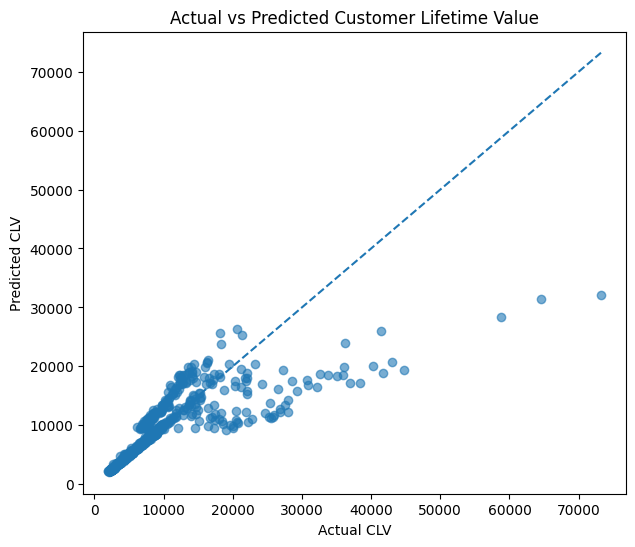

In [20]:
# prediksi final model XGBoost after tuning
y_pred_xgb_log = best_xgb.predict(X_test)
y_pred_xgb = np.expm1(y_pred_xgb_log)

# scatter plot actual vs predicted
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_xgb, alpha=0.6)

min_val = min(y_test.min(), y_pred_xgb.min())
max_val = max(y_test.max(), y_pred_xgb.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

plt.title('Actual vs Predicted Customer Lifetime Value')
plt.xlabel('Actual CLV')
plt.ylabel('Predicted CLV')
plt.show()

Plot ini digunakan untuk membandingkan nilai CLV aktual dan nilai CLV hasil prediksi model. Semakin dekat titik-titik data dengan garis diagonal, semakin baik prediksi model.

Jika terdapat banyak titik yang jauh dari garis diagonal, hal tersebut menunjukkan bahwa model masih memiliki error yang cukup besar pada beberapa customer, terutama kemungkinan pada customer dengan nilai CLV ekstrem.

**Residual Plot XGBoost After Tuning Plot**

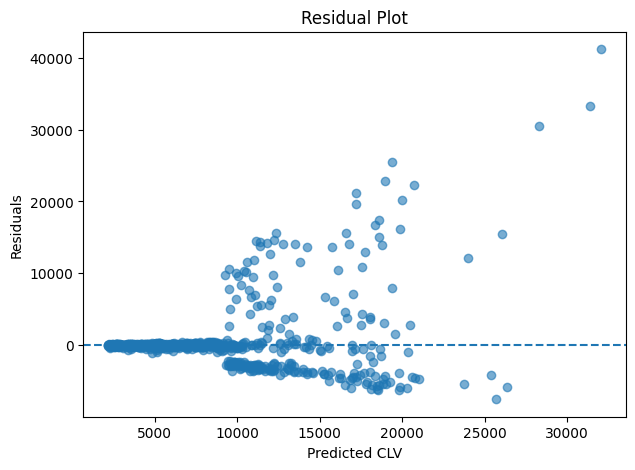

In [21]:
# residual dari final model XGBoost after tuning
residuals = y_test - y_pred_xgb

plt.figure(figsize=(7, 5))
plt.scatter(y_pred_xgb, residuals, alpha=0.6)
plt.axhline(0, linestyle='--')

plt.title('Residual Plot')
plt.xlabel('Predicted CLV')
plt.ylabel('Residuals')
plt.show()

Residual plot digunakan untuk melihat pola error model. Residual adalah selisih antara nilai aktual dan nilai prediksi. Model yang baik idealnya memiliki residual yang tersebar secara acak di sekitar garis nol.

Jika residual membentuk pola tertentu, maka model kemungkinan masih belum menangkap sebagian pola dalam data. Plot ini juga membantu melihat apakah error menjadi lebih besar pada prediksi CLV tertentu, terutama pada nilai CLV tinggi.

**Top 15 Feature Importance XGBoost After Tuning Plot**

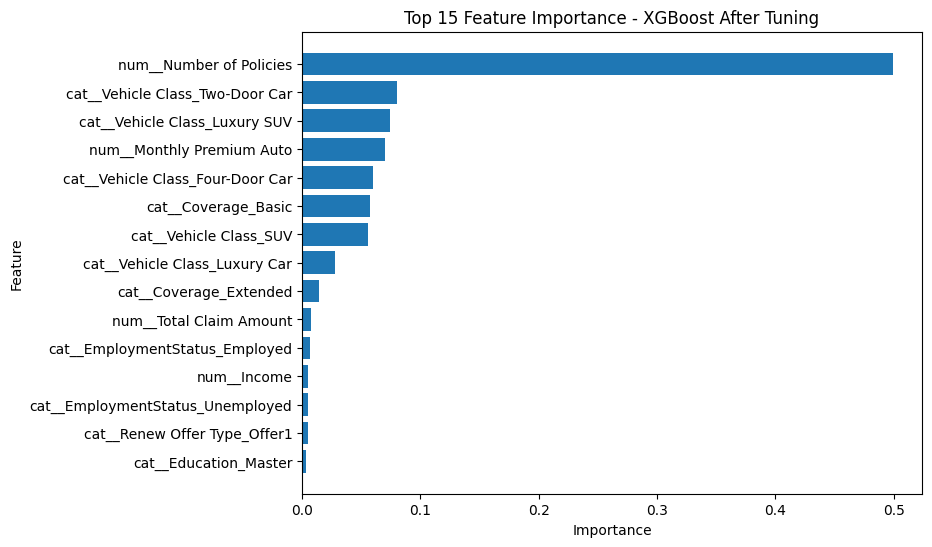

In [22]:
# plot top 15 feature importance dari final model XGBoost
feature_importance_df = pd.DataFrame({
    'Feature': best_xgb.named_steps['preprocessor'].get_feature_names_out(),
    'Importance': best_xgb.named_steps['model'].feature_importances_
}).sort_values(by='Importance', ascending=False)

top_features = feature_importance_df.head(15).sort_values(by='Importance')

plt.figure(figsize=(8, 6))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.title('Top 15 Feature Importance - XGBoost After Tuning')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

Plot ini menampilkan 15 fitur dengan importance tertinggi pada final model. Visualisasi ini membantu melihat fitur mana yang paling dominan digunakan model dalam memprediksi `Customer Lifetime Value`.

Insight dari feature importance dapat digunakan untuk menjelaskan faktor-faktor yang paling berkontribusi terhadap prediksi CLV, meskipun hasilnya tetap perlu diinterpretasikan dengan hati-hati karena bukan hubungan kausal langsung.

**Modeling Summary**

Final model yang dipilih adalah **XGBoost setelah tuning** dengan performa terbaik, yaitu **RMSE 3922.69**, **MAE 1462.40**, dan **R² 0.6767**. Model ini dapat digunakan sebagai alat bantu untuk mengestimasi **Customer Lifetime Value** dan mendukung prioritas strategi retensi serta pemasaran pelanggan.

## 5. Conclusion

Berdasarkan proses modeling yang telah dilakukan, **XGBoost setelah hyperparameter tuning** dipilih sebagai **final model** karena memberikan performa terbaik dibandingkan baseline model dan Random Forest, dengan nilai **RMSE, MAE, dan R²** yang paling baik.

Model ini dapat digunakan untuk membantu perusahaan dalam **mengestimasi Customer Lifetime Value (CLV)** sehingga tim bisnis dapat lebih mudah melakukan **prioritas pelanggan, penyusunan strategi retensi, dan pengambilan keputusan pemasaran** secara lebih terarah.

Namun, model ini lebih layak digunakan pada data pelanggan dengan pola yang mirip dengan data training. Prediksi model menjadi **kurang dapat dipercaya** untuk pelanggan dengan karakteristik yang sangat berbeda atau pada nilai CLV yang sangat ekstrem, karena error prediksi masih bisa cukup besar.

Secara keseluruhan, model ini sudah memberikan peningkatan yang jelas dibandingkan baseline model, tetapi masih memiliki keterbatasan dari sisi fitur dan data yang digunakan.

## 6. Recommendation

1. Model ini dapat digunakan sebagai **alat bantu estimasi awal CLV**, bukan sebagai satu-satunya dasar keputusan bisnis. Hasil prediksi tetap perlu dipadukan dengan pertimbangan bisnis lain.

2. Untuk meningkatkan performa model, perusahaan dapat menambahkan fitur yang lebih relevan, seperti **riwayat transaksi pelanggan, durasi hubungan pelanggan, frekuensi pembelian, atau riwayat interaksi layanan**.

3. Perlu dilakukan evaluasi berkala jika model akan digunakan pada data baru, karena performa model bisa menurun ketika pola pelanggan berubah dari data training.

4. Pada pengembangan berikutnya, model dapat diuji dengan validasi yang lebih kuat atau data yang lebih lengkap agar hasil prediksi menjadi lebih stabil dan lebih dapat dipercaya.

In [23]:
import pickle

# menyimpan final model XGBoost after tuning
with open('final_xgboost_clv_model.pkl', 'wb') as file:
    pickle.dump(best_xgb, file)

Model yang disimpan sudah mencakup preprocessing dan algoritma final, sehingga dapat digunakan kembali untuk melakukan prediksi pada data baru dengan struktur fitur yang sama.